# [Global Temporal Split] Feature-Enhanced NCF Stage 3

**Purpose:** Train and evaluate Stage 3 only.  
Stages 1 and 2 are already complete. This notebook rebuilds the required  
intermediate data and runs Stage 3 directly.

**Note:** For the sake of saving RAM usage after multiple crashes, Stage 3 Feature Enhanced NCF was run separately on this notebook

**Stage 3 adds on top of Stage 2:**
- User-item matching: `user_author_interaction_share_before_t`, `num_pages_preference_gap`, `user_profile_embedding_similarity`
- User history: `user_hist_interaction_count_before_t`, `user_hist_author_diversity_before_t`, `days_since_user_last_interaction`

# Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

from google.colab import drive
drive.mount('/content/drive')
DATA_DIR  = '/content/drive/My Drive/BT4222Project/'

SEED = 4222
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = 10

print(f"Device : {DEVICE}")
print(f"K      : {K}")

Mounted at /content/drive
Device : cuda
K      : 10


# Load Splits

We load the global temporal train, validation, and test interaction files. The validation and test files are the **warm-start** subsets, meaning cold-start users and items have already been removed before this notebook.

For each split:
- `user_id` and `book_id` are cast to string
- `event_time` is parsed as datetime
- rows missing any core field (`user_id`, `book_id`, or `event_time`) are dropped
- rows are sorted by `user_id` and `event_time`



In [ ]:
train_df = pd.read_pickle(DATA_DIR + "App2_train.pkl")
val_df   = pd.read_pickle(DATA_DIR + "App2_val_ws.pkl")
test_df  = pd.read_pickle(DATA_DIR + "App2_test_ws.pkl")

for df in [train_df, val_df, test_df]:
    df["user_id"]    = df["user_id"].astype(str)
    df["book_id"]    = df["book_id"].astype(str)
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

    # Drop rows missing core keys
    df.dropna(subset=["user_id", "book_id", "event_time"], inplace=True)

    df.sort_values(["user_id", "event_time"], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"Train : {len(train_df):,} rows  |  {train_df['user_id'].nunique():,} users")
print(f"Val   : {len(val_df):,} rows  |  {val_df['user_id'].nunique():,} users")
print(f"Test  : {len(test_df):,} rows  |  {test_df['user_id'].nunique():,} users")
print(f"\nColumns: {train_df.columns.tolist()}")

Train : 7,454,809 rows  |  410,740 users
Val   : 612,745 rows  |  85,098 users
Test  : 259,317 rows  |  50,011 users

Columns: ['user_id', 'book_id', 'review_id', 'event_time', 'title', 'description', 'description_truncated', 'has_meaningful_description', 'publication_year', 'num_pages', 'language_code_collapsed', 'format_collapsed', 'is_ebook', 'authors_standardized', 'main_author_id', 'author_interactions_count_before_t', 'top_shelf_tags', 'item_text_for_embedding', 'item_semantic_embedding_static', 'item_num_pages', 'user_page_preference_before_t', 'num_pages_preference_gap', 'user_hist_interaction_count_before_t', 'days_since_user_last_interaction', 'book_interactions_count_before_t', 'days_since_book_last_interaction', 'user_author_interaction_share_before_t', 'user_hist_author_diversity_before_t', 'user_profile_embedding_similarity']


In [ ]:
train_users = set(train_df["user_id"].unique())
train_items = set(train_df["book_id"].unique())

assert set(val_df["user_id"].unique()).issubset(train_users)
assert set(test_df["user_id"].unique()).issubset(train_users)
assert set(val_df["book_id"].unique()).issubset(train_items)
assert set(test_df["book_id"].unique()).issubset(train_items)

print("Warm-start checks passed.")

Warm-start checks passed.


# Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
item_enc = LabelEncoder()

user_enc.fit(train_df["user_id"])
item_enc.fit(train_df["book_id"])

num_users = len(user_enc.classes_)
num_items = len(item_enc.classes_)

N_train = len(train_df)
density_train = N_train / (num_users * num_items)

print(f"Train users (U)       : {num_users:,}")
print(f"Train items (I)       : {num_items:,}")
print(f"Train interactions    : {N_train:,}")
print(f"Train density         : {density_train * 100:.6f}%")

N_all = len(train_df) + len(val_df) + len(test_df)
print(f"Total rows (all splits): {N_all:,}")

def encode_df(df, user_enc, item_enc):
    user_mask = df["user_id"].isin(user_enc.classes_)
    item_mask = df["book_id"].isin(item_enc.classes_)

    d = df.loc[user_mask & item_mask].copy()
    d["user_idx"] = user_enc.transform(d["user_id"])
    d["item_idx"] = item_enc.transform(d["book_id"])
    return d

train_enc = encode_df(train_df, user_enc, item_enc)
val_enc   = encode_df(val_df, user_enc, item_enc)
test_enc  = encode_df(test_df, user_enc, item_enc)

print(f"\nEncoded train : {len(train_enc):,} rows")
print(f"Encoded val   : {len(val_enc):,} rows")
print(f"Encoded test  : {len(test_enc):,} rows")

print("\nRows dropped during encoding:")
print(f"Val dropped   : {len(val_df) - len(val_enc):,}")
print(f"Test dropped  : {len(test_df) - len(test_enc):,}")

assert len(train_enc) == len(train_df), "Train should not lose rows during encoding"
assert len(val_enc) == len(val_df), "Some val rows were unexpectedly dropped during encoding"
assert len(test_enc) == len(test_df), "Some test rows were unexpectedly dropped during encoding"

print("\nEncoding coverage checks passed.")

Train users (U)       : 410,740
Train items (I)       : 114,452
Train interactions    : 7,454,809
Train density         : 0.015858%
Total rows (all splits): 8,326,871

Encoded train : 7,454,809 rows
Encoded val   : 612,745 rows
Encoded test  : 259,317 rows

Rows dropped during encoding:
Val dropped   : 0
Test dropped  : 0

Encoding coverage checks passed.


# Categorical Encoding on Side Features

This step converts text categories into integer IDs so they can be used by the model.

We create mappings for:
- `format_collapsed`
- `language_code_collapsed`
- `main_author_id`

The mappings are built using the **training set only**, then reused for validation and test. This avoids data leakage.

If a value is missing, or if a category appears in validation/test but was not seen in training, it is mapped to `"unknown"`.

In [ ]:
# =========================================================
# Fit side-feature categorical encoders on TRAIN ONLY
# and transform train / val / test using train mappings
# =========================================================

def make_safe_mapping(series):
    vals = series.fillna("unknown").astype(str).unique().tolist()
    if "unknown" not in vals:
        vals.append("unknown")
    vals = sorted(vals)
    return {v: i for i, v in enumerate(vals)}

# Fit on TRAIN ONLY
format2idx = make_safe_mapping(train_df["format_collapsed"])
lang2idx   = make_safe_mapping(train_df["language_code_collapsed"])
author2idx = make_safe_mapping(train_df["main_author_id"])

num_formats = len(format2idx)
num_langs   = len(lang2idx)
num_authors = len(author2idx)

print(f"Formats  : {num_formats}")
print(f"Languages: {num_langs}")
print(f"Authors  : {num_authors}")

def encode_categoricals(df):
    d = df.copy()

    d["format_idx"] = (
        d["format_collapsed"]
        .fillna("unknown")
        .astype(str)
        .map(lambda x: format2idx.get(x, format2idx["unknown"]))
    )

    d["lang_idx"] = (
        d["language_code_collapsed"]
        .fillna("unknown")
        .astype(str)
        .map(lambda x: lang2idx.get(x, lang2idx["unknown"]))
    )

    d["author_idx"] = (
        d["main_author_id"]
        .fillna("unknown")
        .astype(str)
        .map(lambda x: author2idx.get(x, author2idx["unknown"]))
    )

    return d

train_enc = encode_categoricals(train_enc)
val_enc   = encode_categoricals(val_enc)
test_enc  = encode_categoricals(test_enc)

print("Categorical encoding done.")

Formats  : 11
Languages: 76
Authors  : 23545
Categorical encoding done.


# Numerical Feature Scaling

Numerical side features are standardised using `StandardScaler` so they are on a comparable scale before being fed into the model.

The scaler is **fit on the training set only**, then the same transformation is applied to validation and test. This avoids data leakage from future splits.

Any missing values are filled with `0` before scaling. Only numerical columns that are present in the encoded dataframes are scaled.

In [ ]:
from sklearn.preprocessing import StandardScaler

# All numerical side features across all stages
NUMERICAL_COLS = [
    # Stage 2 — item metadata
    "num_pages", "publication_year",
    # Stage 2 — item temporal popularity
    "book_interactions_count_before_t",
    "days_since_book_last_interaction",
    "author_interactions_count_before_t",
    # Stage 3 — user-item matching
    "num_pages_preference_gap",
    "user_profile_embedding_similarity",
    # Stage 3 — user history
    "user_hist_interaction_count_before_t",
    "user_hist_author_diversity_before_t",
    # already 0-1 but scale anyway for consistency
    "user_author_interaction_share_before_t",
]

NUMERICAL_COLS = [c for c in NUMERICAL_COLS if c in train_enc.columns]
print(f"Scaling {len(NUMERICAL_COLS)} numerical columns")

scaler = StandardScaler()
train_enc[NUMERICAL_COLS] = scaler.fit_transform(
    train_enc[NUMERICAL_COLS].fillna(0)
)
val_enc[NUMERICAL_COLS] = scaler.transform(
    val_enc[NUMERICAL_COLS].fillna(0)
)
test_enc[NUMERICAL_COLS] = scaler.transform(
    test_enc[NUMERICAL_COLS].fillna(0)
)

print("Scaling done.")

Scaling 10 numerical columns
Scaling done.


# Negative Sampling (Top-1000 Popular Books)

Same negative sampling strategy as the ID-only NCF baseline.

- Observed training interactions are treated as positive samples.
- For each user, negative samples are drawn at an approximate **1:1 ratio** from the **top-1000 most popular books in the training set**.
- Books the user has already interacted with in the **training split** are excluded from that user’s negative pool.

In [ ]:
from time import perf_counter
from tqdm.auto import tqdm
import numpy as np
import pandas as pd

start_t = perf_counter()

# =========================================================
# 1. Top-1000 most popular books from TRAIN ONLY
# =========================================================
top_1000_books = (
    train_df.groupby("book_id").size()
    .sort_values(ascending=False)
    .head(1000)
    .index.tolist()
)

item_class_set = set(item_enc.classes_)
top_1000_books = [b for b in top_1000_books if b in item_class_set]
top_1000_idx = item_enc.transform(top_1000_books).astype(np.int32)

print(f"Top-1000 pool size: {len(top_1000_idx)}")

# =========================================================
# 2. TRAIN-ONLY user history
# =========================================================
user_train_history_idx = (
    train_enc.groupby("user_id")["item_idx"]
    .apply(lambda x: set(x.astype(np.int32)))
    .to_dict()
)

# =========================================================
# 3. Positive rows: keep only IDs + label
# =========================================================
pos = train_enc[["user_idx", "item_idx"]].copy()
pos["user_idx"] = pos["user_idx"].astype(np.int32)
pos["item_idx"] = pos["item_idx"].astype(np.int32)
pos["label"] = np.int8(1)

# =========================================================
# 4. Precompute helpers
# =========================================================
user_pos_counts = train_enc.groupby("user_id").size().sort_index()

user_to_idx = (
    train_enc.drop_duplicates("user_id")
    .set_index("user_id")["user_idx"]
    .astype(np.int32)
    .to_dict()
)

rng = np.random.default_rng(SEED)
neg_user_chunks = []
neg_item_chunks = []

for user_id, n_pos in tqdm(
    user_pos_counts.items(),
    total=len(user_pos_counts),
    desc="Negative sampling",
    unit="user"
):
    seen_idx = user_train_history_idx.get(user_id, set())

    if seen_idx:
        mask = ~np.isin(top_1000_idx, list(seen_idx))
        pool_idx = top_1000_idx[mask]
    else:
        pool_idx = top_1000_idx

    n_neg = min(int(n_pos), int(pool_idx.size))
    if n_neg == 0:
        continue

    sampled_idx = rng.choice(pool_idx, size=n_neg, replace=False)
    neg_user_chunks.append(np.full(n_neg, user_to_idx[user_id], dtype=np.int32))
    neg_item_chunks.append(sampled_idx.astype(np.int32))

# =========================================================
# 5. Negative rows: keep only IDs + label
# =========================================================
if neg_user_chunks:
    neg = pd.DataFrame({
        "user_idx": np.concatenate(neg_user_chunks),
        "item_idx": np.concatenate(neg_item_chunks),
        "label": np.int8(0),
    })
else:
    neg = pd.DataFrame(columns=["user_idx", "item_idx", "label"])

# =========================================================
# 6. Combine and shuffle
# =========================================================
train_with_neg = pd.concat([pos, neg], ignore_index=True)
train_with_neg = train_with_neg.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nTrain positives        : {len(pos):,}")
print(f"Train negatives        : {len(neg):,}")
print(f"Train rows (with negs) : {len(train_with_neg):,}")
print("\nLabel counts:")
print(train_with_neg["label"].value_counts())
print(f"\nNegative sampling time: {perf_counter() - start_t:.1f}s")

Top-1000 pool size: 1000


Negative sampling:   0%|          | 0/410740 [00:00<?, ?user/s]


Train positives        : 7,454,809
Train negatives        : 7,104,278
Train rows (with negs) : 14,559,087

Label counts:
label
1    7454809
0    7104278
Name: count, dtype: int64

Negative sampling time: 22.9s


## Stage 3 Feature Groups

This section defines the item, user, and pair-specific feature groups used in Stage 3.

In [ ]:
# =========================================================
# Stage 3 feature groups
# =========================================================

ITEM_CAT_COLS_STAGE3 = [
    c for c in ["format_idx", "lang_idx", "author_idx"]
    if c in train_enc.columns
]

ITEM_NUM_COLS_STAGE3 = [
    c for c in [
        "num_pages",
        "publication_year",
        "book_interactions_count_before_t",
        "days_since_book_last_interaction",
        "author_interactions_count_before_t",
    ]
    if c in train_enc.columns
]

USER_NUM_COLS_STAGE3 = [
    c for c in [
        "user_hist_interaction_count_before_t",
        "user_hist_author_diversity_before_t",
    ]
    if c in train_enc.columns
]

PAIR_NUM_COLS_STAGE3 = [
    c for c in [
        "user_author_interaction_share_before_t",
        "num_pages_preference_gap",
        "user_profile_embedding_similarity",
    ]
    if c in train_enc.columns
]

SBERT_COL = "item_semantic_embedding_static" if "item_semantic_embedding_static" in train_enc.columns else None

print("ITEM_CAT_COLS_STAGE3 :", ITEM_CAT_COLS_STAGE3)
print("ITEM_NUM_COLS_STAGE3 :", ITEM_NUM_COLS_STAGE3)
print("USER_NUM_COLS_STAGE3 :", USER_NUM_COLS_STAGE3)
print("PAIR_NUM_COLS_STAGE3 :", PAIR_NUM_COLS_STAGE3)
print("SBERT_COL           :", SBERT_COL)

ITEM_CAT_COLS_STAGE3 : ['format_idx', 'lang_idx', 'author_idx']
ITEM_NUM_COLS_STAGE3 : ['num_pages', 'publication_year', 'book_interactions_count_before_t', 'days_since_book_last_interaction', 'author_interactions_count_before_t']
USER_NUM_COLS_STAGE3 : ['user_hist_interaction_count_before_t', 'user_hist_author_diversity_before_t']
PAIR_NUM_COLS_STAGE3 : ['user_author_interaction_share_before_t', 'num_pages_preference_gap', 'user_profile_embedding_similarity']
SBERT_COL           : item_semantic_embedding_static


## Stage 3 Lookup Matrices

Item-side features are first organised into lookup matrices indexed by `item_idx` so they can be retrieved efficiently during training and evaluation.

At this stage, the user numerical lookup is still a placeholder and is built later, after the train-side user history summaries have been constructed.

In [ ]:
# =========================================================
# Stage 3 lookup matrices
# =========================================================

import numpy as np
import pandas as pd

# -----------------------------
# Item categorical lookup
# -----------------------------
if ITEM_CAT_COLS_STAGE3:
    item_cat_df_s3 = (
        train_enc[["item_idx"] + ITEM_CAT_COLS_STAGE3]
        .drop_duplicates("item_idx")
        .sort_values("item_idx")
        .set_index("item_idx")
    )
    item_cat_matrix_s3 = item_cat_df_s3.to_numpy(dtype=np.int64)
else:
    item_cat_matrix_s3 = None

# -----------------------------
# Item numerical lookup
# -----------------------------
if ITEM_NUM_COLS_STAGE3:
    item_num_df_s3 = (
        train_enc[["item_idx"] + ITEM_NUM_COLS_STAGE3]
        .drop_duplicates("item_idx")
        .sort_values("item_idx")
        .set_index("item_idx")
    )
    item_num_matrix_s3 = item_num_df_s3.to_numpy(dtype=np.float32)
else:
    item_num_matrix_s3 = None

# -----------------------------
# Placeholder for user numerical lookup
# build this later after train_user_state_lookup exists
# -----------------------------
user_num_matrix_s3 = None

# -----------------------------
# Item SBERT lookup
# -----------------------------
if SBERT_COL is not None:
    item_sbert_df_s3 = (
        train_enc[["item_idx", SBERT_COL]]
        .drop_duplicates("item_idx")
        .sort_values("item_idx")
        .set_index("item_idx")
    )
    item_sbert_matrix_s3 = np.vstack(
        item_sbert_df_s3[SBERT_COL].values
    ).astype(np.float32)
else:
    item_sbert_matrix_s3 = None

print("item_cat_matrix_s3   :", None if item_cat_matrix_s3 is None else item_cat_matrix_s3.shape)
print("item_num_matrix_s3   :", None if item_num_matrix_s3 is None else item_num_matrix_s3.shape)
print("user_num_matrix_s3   :", user_num_matrix_s3)
print("item_sbert_matrix_s3 :", None if item_sbert_matrix_s3 is None else item_sbert_matrix_s3.shape)

item_cat_matrix_s3   : (114452, 3)
item_num_matrix_s3   : (114452, 5)
user_num_matrix_s3   : None
item_sbert_matrix_s3 : (114452, 384)


In [ ]:
# =========================================================
# Stage 3 lookup checks
# =========================================================

if item_cat_matrix_s3 is not None:
    assert item_cat_matrix_s3.shape[0] == num_items

if item_num_matrix_s3 is not None:
    assert item_num_matrix_s3.shape[0] == num_items

if user_num_matrix_s3 is not None:
    assert user_num_matrix_s3.shape[0] == num_users

if item_sbert_matrix_s3 is not None:
    assert item_sbert_matrix_s3.shape[0] == num_items
    assert item_sbert_matrix_s3.shape[1] == 384

print("Stage 3 lookup checks passed.")

Stage 3 lookup checks passed.


In [ ]:
# =========================================================
# Stage 3 eval-time raw item lookups
# =========================================================

item_static_raw = (
    train_df[["book_id", "main_author_id", "num_pages", "item_semantic_embedding_static"]]
    .drop_duplicates("book_id")
    .copy()
)

item_static_raw["book_id"] = item_static_raw["book_id"].astype(str)
item_static_raw["main_author_id"] = item_static_raw["main_author_id"].fillna("unknown").astype(str)
item_static_raw["num_pages"] = pd.to_numeric(item_static_raw["num_pages"], errors="coerce")
item_static_raw = item_static_raw.set_index("book_id")

book_ids_by_idx = list(item_enc.classes_)

item_author_raw_by_idx = np.array([
    item_static_raw.at[bid, "main_author_id"] if bid in item_static_raw.index else "unknown"
    for bid in book_ids_by_idx
], dtype=object)

item_num_pages_raw_by_idx = np.array([
    item_static_raw.at[bid, "num_pages"] if bid in item_static_raw.index else np.nan
    for bid in book_ids_by_idx
], dtype=np.float32)

scaler_mean_map = dict(zip(NUMERICAL_COLS, scaler.mean_))
scaler_scale_map = dict(zip(NUMERICAL_COLS, scaler.scale_))

print("Raw item lookups ready.")
print("item_author_raw_by_idx:", item_author_raw_by_idx.shape)
print("item_num_pages_raw_by_idx:", item_num_pages_raw_by_idx.shape)

Raw item lookups ready.
item_author_raw_by_idx: (114452,)
item_num_pages_raw_by_idx: (114452,)


## Stage 3 Evaluation-Time Pair Feature Construction

At evaluation time, pair-specific matching features must be rebuilt for each user–candidate set using the user’s train-only history and the candidate item features.

In [ ]:
# =========================================================
# Stage 3 eval-time feature helpers
# =========================================================

def scale_feature_array(values, col_name, scaler_mean_map, scaler_scale_map):
    values = np.asarray(values, dtype=np.float32)
    mean = scaler_mean_map[col_name]
    scale = scaler_scale_map[col_name]
    if scale == 0:
        return values - mean
    return (values - mean) / scale


def cosine_similarity_block(user_vec, item_mat):
    if user_vec is None:
        return np.zeros(item_mat.shape[0], dtype=np.float32)

    user_norm = np.linalg.norm(user_vec)
    item_norms = np.linalg.norm(item_mat, axis=1)

    valid = (user_norm > 0) & (item_norms > 0)
    sims = np.zeros(item_mat.shape[0], dtype=np.float32)

    if np.any(valid):
        sims[valid] = (item_mat[valid] @ user_vec) / (item_norms[valid] * user_norm)

    return sims.astype(np.float32)


def build_stage3_num_block_for_candidates(
    uid,
    candidate_idx,
    user_state_lookup,
    item_num_matrix,
    item_author_raw_by_idx,
    item_num_pages_raw_by_idx,
    item_sbert_matrix,
    scaler_mean_map,
    scaler_scale_map,
):
    state = user_state_lookup.get(uid, {
        "interaction_count": 0.0,
        "author_diversity": 0.0,
        "days_since_last": 0.0,
        "author_counts": {},
        "avg_num_pages": np.nan,
        "profile_emb": None,
    })

    n_cands = len(candidate_idx)
    num_parts = []

    # -----------------------------
    # Item numerical block
    # already scaled in item_num_matrix
    # -----------------------------
    if item_num_matrix is not None:
        num_parts.append(item_num_matrix[candidate_idx])

    # -----------------------------
    # User-only block
    # raw -> scale -> repeat
    # -----------------------------
    user_hist_count_raw = state["interaction_count"]
    user_author_div_raw = state["author_diversity"]

    user_block = np.column_stack([
        np.full(
            n_cands,
            scale_feature_array(
                [user_hist_count_raw],
                "user_hist_interaction_count_before_t",
                scaler_mean_map,
                scaler_scale_map
            )[0],
            dtype=np.float32
        ),
        np.full(
            n_cands,
            scale_feature_array(
                [user_author_div_raw],
                "user_hist_author_diversity_before_t",
                scaler_mean_map,
                scaler_scale_map
            )[0],
            dtype=np.float32
        ),
    ]).astype(np.float32)

    num_parts.append(user_block)

    # -----------------------------
    # Pair-specific block
    # raw -> scale
    # -----------------------------
    candidate_authors = item_author_raw_by_idx[candidate_idx]
    candidate_pages = item_num_pages_raw_by_idx[candidate_idx]

    interaction_count = state["interaction_count"]
    author_counts = state["author_counts"]
    avg_pages = state["avg_num_pages"]
    profile_emb = state["profile_emb"]

    if interaction_count > 0:
        author_share_raw = np.array(
            [author_counts.get(a, 0) / interaction_count for a in candidate_authors],
            dtype=np.float32
        )
    else:
        author_share_raw = np.zeros(n_cands, dtype=np.float32)

    if np.isfinite(avg_pages):
        pages_gap_raw = np.abs(candidate_pages - avg_pages).astype(np.float32)
        pages_gap_raw = np.nan_to_num(pages_gap_raw, nan=0.0, posinf=0.0, neginf=0.0)
    else:
        pages_gap_raw = np.zeros(n_cands, dtype=np.float32)

    if item_sbert_matrix is not None:
        candidate_embs = item_sbert_matrix[candidate_idx]
        profile_sim_raw = cosine_similarity_block(profile_emb, candidate_embs)
    else:
        profile_sim_raw = np.zeros(n_cands, dtype=np.float32)

    pair_block = np.column_stack([
        scale_feature_array(
            author_share_raw,
            "user_author_interaction_share_before_t",
            scaler_mean_map,
            scaler_scale_map
        ),
        scale_feature_array(
            pages_gap_raw,
            "num_pages_preference_gap",
            scaler_mean_map,
            scaler_scale_map
        ),
        scale_feature_array(
            profile_sim_raw,
            "user_profile_embedding_similarity",
            scaler_mean_map,
            scaler_scale_map
        ),
    ]).astype(np.float32)

    num_parts.append(pair_block)

    return np.concatenate(num_parts, axis=1).astype(np.float32)

print("Stage 3 eval-time helper functions defined.")

Stage 3 eval-time helper functions defined.


## Stage 3 Training Pair Features

For the training set, pair-specific matching features are computed for every sampled positive and negative user–item pair so that negatives receive the correct user-item matching values.

In [ ]:
# =========================================================
# Stage 3 train dataframe with proper pair features
# =========================================================

def build_stage3_pair_features_for_train_df(
    df,
    user_idx_to_state,
    item_idx_to_author_raw,
    item_idx_to_num_pages_raw,
    item_sbert_matrix,
    scaler_mean_map,
    scaler_scale_map,
):
    user_author_share_vals = []
    num_pages_gap_vals = []
    profile_sim_vals = []

    for row in tqdm(df.itertuples(index=False), total=len(df), desc="Building Stage 3 train pair features"):
        uidx = int(row.user_idx)
        iidx = int(row.item_idx)

        state = user_idx_to_state.get(uidx, {
            "interaction_count": 0.0,
            "author_counts": {},
            "avg_num_pages": np.nan,
            "profile_emb": None,
        })

        interaction_count = state["interaction_count"]
        author_counts = state["author_counts"]
        avg_pages = state["avg_num_pages"]
        profile_emb = state["profile_emb"]

        item_author = item_idx_to_author_raw[iidx]
        item_pages = item_idx_to_num_pages_raw[iidx]

        # user_author_interaction_share_before_t
        if interaction_count > 0:
            author_share_raw = author_counts.get(item_author, 0) / interaction_count
        else:
            author_share_raw = 0.0

        # num_pages_preference_gap
        if np.isfinite(avg_pages) and np.isfinite(item_pages):
            pages_gap_raw = abs(item_pages - avg_pages)
        else:
            pages_gap_raw = 0.0

        # user_profile_embedding_similarity
        if profile_emb is not None and item_sbert_matrix is not None:
            item_vec = item_sbert_matrix[iidx]
            user_norm = np.linalg.norm(profile_emb)
            item_norm = np.linalg.norm(item_vec)
            if user_norm > 0 and item_norm > 0:
                profile_sim_raw = float(np.dot(profile_emb, item_vec) / (user_norm * item_norm))
            else:
                profile_sim_raw = 0.0
        else:
            profile_sim_raw = 0.0

        user_author_share_vals.append(author_share_raw)
        num_pages_gap_vals.append(pages_gap_raw)
        profile_sim_vals.append(profile_sim_raw)

    out = df.copy()

    out["user_author_interaction_share_before_t"] = scale_feature_array(
        user_author_share_vals,
        "user_author_interaction_share_before_t",
        scaler_mean_map,
        scaler_scale_map,
    ).astype(np.float32)

    out["num_pages_preference_gap"] = scale_feature_array(
        num_pages_gap_vals,
        "num_pages_preference_gap",
        scaler_mean_map,
        scaler_scale_map,
    ).astype(np.float32)

    out["user_profile_embedding_similarity"] = scale_feature_array(
        profile_sim_vals,
        "user_profile_embedding_similarity",
        scaler_mean_map,
        scaler_scale_map,
    ).astype(np.float32)

    return out


# ---------------------------------------------------------
# Build TRAIN-side user state lookup from train history
# ---------------------------------------------------------
train_user_state_by_uid = (
    train_df.sort_values(["user_id", "event_time"])
    .groupby("user_id")
)

train_user_state_lookup = {}

for uid, grp in tqdm(train_user_state_by_uid, desc="Building train user state"):
    grp = grp.copy()
    grp["main_author_id"] = grp["main_author_id"].fillna("unknown").astype(str)
    grp["num_pages"] = pd.to_numeric(grp["num_pages"], errors="coerce")

    interaction_count = float(len(grp))
    author_counts = grp["main_author_id"].value_counts().to_dict()
    avg_pages = float(grp["num_pages"].dropna().mean()) if grp["num_pages"].notna().any() else np.nan

    emb_list = [
        x for x in grp["item_semantic_embedding_static"].tolist()
        if isinstance(x, np.ndarray) and x.ndim == 1
    ]
    profile_emb = np.mean(np.vstack(emb_list), axis=0).astype(np.float32) if emb_list else None

    train_user_state_lookup[uid] = {
        "interaction_count": interaction_count,
        "author_counts": author_counts,
        "avg_num_pages": avg_pages,
        "profile_emb": profile_emb,
    }

# map from user_idx to state
uid_to_user_idx = (
    train_enc.drop_duplicates("user_id")
    .set_index("user_id")["user_idx"]
    .to_dict()
)

user_idx_to_train_state = {
    uid_to_user_idx[uid]: state
    for uid, state in train_user_state_lookup.items()
    if uid in uid_to_user_idx
}

# ---------------------------------------------------------
# Raw item lookups by item_idx for train-time pair features
# ---------------------------------------------------------
train_item_static_raw = (
    train_df[["book_id", "main_author_id", "num_pages"]]
    .drop_duplicates("book_id")
    .copy()
)

train_item_static_raw["book_id"] = train_item_static_raw["book_id"].astype(str)
train_item_static_raw["main_author_id"] = train_item_static_raw["main_author_id"].fillna("unknown").astype(str)
train_item_static_raw["num_pages"] = pd.to_numeric(train_item_static_raw["num_pages"], errors="coerce")
train_item_static_raw = train_item_static_raw.set_index("book_id")

book_ids_by_idx = list(item_enc.classes_)

item_author_raw_by_idx_train = np.array([
    train_item_static_raw.at[bid, "main_author_id"] if bid in train_item_static_raw.index else "unknown"
    for bid in book_ids_by_idx
], dtype=object)

item_num_pages_raw_by_idx_train = np.array([
    train_item_static_raw.at[bid, "num_pages"] if bid in train_item_static_raw.index else np.nan
    for bid in book_ids_by_idx
], dtype=np.float32)

# ---------------------------------------------------------
# Build proper Stage 3 training dataframe
# ---------------------------------------------------------
train_with_neg_s3 = build_stage3_pair_features_for_train_df(
    df=train_with_neg.copy(),
    user_idx_to_state=user_idx_to_train_state,
    item_idx_to_author_raw=item_author_raw_by_idx_train,
    item_idx_to_num_pages_raw=item_num_pages_raw_by_idx_train,
    item_sbert_matrix=item_sbert_matrix_s3,
    scaler_mean_map=scaler_mean_map,
    scaler_scale_map=scaler_scale_map,
)

print("train_with_neg_s3 shape:", train_with_neg_s3.shape)
print(
    train_with_neg_s3[
        ["user_idx", "item_idx", "label"] + PAIR_NUM_COLS_STAGE3
    ].head()
)

Building train user state:   0%|          | 0/410740 [00:00<?, ?it/s]

Building Stage 3 train pair features:   0%|          | 0/14559087 [00:00<?, ?it/s]

train_with_neg_s3 shape: (14559087, 6)
   user_idx  item_idx  label  user_author_interaction_share_before_t  \
0     13574     15176      1                               -0.216934   
1    153276     31671      0                               -0.374275   
2    144914    107024      1                               -0.141542   
3    168999     79322      1                               -0.281182   
4    117179     87647      0                               -0.374275   

   num_pages_preference_gap  user_profile_embedding_similarity  
0                 -0.328465                           0.372313  
1                 -0.559342                           0.567115  
2                 -0.243402                          -0.028678  
3                  0.020684                           1.178264  
4                  0.650510                          -2.798115  


In [ ]:
# =========================================================
# Stage 3 user numerical lookup
# Build from full TRAIN-side user state, then scale consistently
# =========================================================

if USER_NUM_COLS_STAGE3:
    user_state_rows = []

    for uid, state in train_user_state_lookup.items():
        if uid not in uid_to_user_idx:
            continue

        row = {
            "user_idx": uid_to_user_idx[uid],
            "user_hist_interaction_count_before_t": state["interaction_count"],
            "user_hist_author_diversity_before_t": len(state["author_counts"]),
        }
        user_state_rows.append(row)

    user_num_df_s3 = pd.DataFrame(user_state_rows)

    for col in USER_NUM_COLS_STAGE3:
        user_num_df_s3[col] = scale_feature_array(
            user_num_df_s3[col].values,
            col,
            scaler_mean_map,
            scaler_scale_map,
        ).astype(np.float32)

    user_num_df_s3 = (
        user_num_df_s3[["user_idx"] + USER_NUM_COLS_STAGE3]
        .sort_values("user_idx")
        .set_index("user_idx")
    )

    user_num_matrix_s3 = user_num_df_s3.to_numpy(dtype=np.float32)
else:
    user_num_matrix_s3 = None

print("user_num_matrix_s3   :", None if user_num_matrix_s3 is None else user_num_matrix_s3.shape)

if user_num_matrix_s3 is not None:
    assert user_num_matrix_s3.shape[0] == num_users

print("Final Stage 3 user lookup check passed.")

user_num_matrix_s3   : (410740, 2)
Final Stage 3 user lookup check passed.


# Dataset and Dataloader

`FeatureNCFDatasetStage3` prepares the training data for Stage 3 by combining multiple feature sources for each user–item pair.

For each training row, the dataset provides:
- `user_idx` and `item_idx`
- the training label
- item categorical features from item lookup matrices
- item numerical features from item lookup matrices
- user numerical features from the user lookup matrix
- pair-specific numerical features stored directly in `train_with_neg_s3`
- item semantic embeddings, if available

These components are merged at retrieval time to form the full Stage 3 model input.

A Stage 3 dataloader is then created for mini-batch training. The fixed sampled validation and test user lists are also reloaded so that ranking evaluation remains consistent across reruns and NCF model variants.

In [ ]:
import torch
from torch.utils.data import Dataset

class FeatureNCFDatasetStage3(Dataset):
    def __init__(
        self,
        df,
        pair_num_cols,
        item_cat_matrix=None,
        item_num_matrix=None,
        item_sbert_matrix=None,
        user_num_matrix=None,
        label_col="label",
    ):
        self.users = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.items = torch.tensor(df["item_idx"].values, dtype=torch.long)
        self.labels = torch.tensor(df[label_col].values, dtype=torch.float32)

        self.pair_num_cols = pair_num_cols
        self.pair_num_feats = None
        if self.pair_num_cols:
            self.pair_num_feats = torch.tensor(
                df[self.pair_num_cols].values,
                dtype=torch.float32
            )

        self.item_cat_matrix = (
            torch.tensor(item_cat_matrix, dtype=torch.long)
            if item_cat_matrix is not None else None
        )
        self.item_num_matrix = (
            torch.tensor(item_num_matrix, dtype=torch.float32)
            if item_num_matrix is not None else None
        )
        self.item_sbert_matrix = (
            torch.tensor(item_sbert_matrix, dtype=torch.float32)
            if item_sbert_matrix is not None else None
        )
        self.user_num_matrix = (
            torch.tensor(user_num_matrix, dtype=torch.float32)
            if user_num_matrix is not None else None
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        user = self.users[idx]
        item = self.items[idx]

        user_i = int(user.item())
        item_i = int(item.item())

        batch = {
            "user": user,
            "item": item,
            "label": self.labels[idx],
        }

        if self.item_cat_matrix is not None:
            batch["cat_feats"] = self.item_cat_matrix[item_i]

        num_parts = []

        if self.item_num_matrix is not None:
            num_parts.append(self.item_num_matrix[item_i])

        if self.user_num_matrix is not None:
            num_parts.append(self.user_num_matrix[user_i])

        if self.pair_num_feats is not None:
            num_parts.append(self.pair_num_feats[idx])

        if num_parts:
            batch["num_feats"] = torch.cat(num_parts, dim=0)

        if self.item_sbert_matrix is not None:
            batch["emb_feats"] = self.item_sbert_matrix[item_i]

        return batch

print("FeatureNCFDatasetStage3 defined.")

FeatureNCFDatasetStage3 defined.


Stage 3 - user-item matching signals + user history features + categorical + numerical + SBERT item features

In [ ]:
from torch.utils.data import DataLoader

train_dataset_s3 = FeatureNCFDatasetStage3(
    train_with_neg_s3,
    pair_num_cols=PAIR_NUM_COLS_STAGE3,
    item_cat_matrix=item_cat_matrix_s3,
    item_num_matrix=item_num_matrix_s3,
    item_sbert_matrix=item_sbert_matrix_s3,
    user_num_matrix=user_num_matrix_s3,
    label_col="label",
)

train_loader_s3 = DataLoader(
    train_dataset_s3,
    batch_size=512,
    shuffle=True,
    pin_memory=True,
)

print(f"Stage 3 train batches: {len(train_loader_s3)}")

Stage 3 train batches: 28436


Build Validation Users from val_df  and Test Users from test_df for final evaluation

In [ ]:
val_sample_user_ids = pd.read_csv(
    DATA_DIR + "global_temporal_val_eval_sample_users.csv"
).iloc[:, 0].astype(str).tolist()

test_sample_user_ids = pd.read_csv(
    DATA_DIR + "global_temporal_test_eval_sample_5k_users.csv"
).iloc[:, 0].astype(str).tolist()

print(f"Loaded {len(val_sample_user_ids):,} val sampled users")
print(f"Loaded {len(test_sample_user_ids):,} test sampled users")

user_train_seen = train_df.groupby("user_id")["book_id"].apply(set).to_dict()

val_true_items_per_user = val_df.groupby("user_id")["book_id"].apply(list).to_dict()
test_true_items_per_user = test_df.groupby("user_id")["book_id"].apply(list).to_dict()

user_to_idx = (
    train_enc.drop_duplicates("user_id")
    .set_index("user_id")["user_idx"]
    .to_dict()
)

item_to_idx = (
    train_enc.drop_duplicates("book_id")
    .set_index("book_id")["item_idx"]
    .to_dict()
)

val_eval_users = [
    (uid, [b for b in val_true_items_per_user[uid] if b in item_to_idx])
    for uid in val_sample_user_ids
    if uid in val_true_items_per_user and uid in user_to_idx
]
val_eval_users = [(uid, books) for uid, books in val_eval_users if books]

test_eval_users = [
    (uid, [b for b in test_true_items_per_user[uid] if b in item_to_idx])
    for uid in test_sample_user_ids
    if uid in test_true_items_per_user and uid in user_to_idx
]
test_eval_users = [(uid, books) for uid, books in test_eval_users if books]

print(f"Validation on {len(val_eval_users):,} users")
print(f"Test evaluation on {len(test_eval_users):,} users")

Loaded 5,000 val sampled users
Loaded 5,000 test sampled users
Validation on 5,000 users
Test evaluation on 5,000 users


## Evaluation-Time User State Lookups

Earlier lookup matrices store static item or user features indexed by `item_idx` or `user_idx`.  
This section is different: it builds **temporal user-state lookups** for validation and test, so that Stage 3 pair-specific matching features can be computed using only the user history available before each target interaction.

In [ ]:
# =========================================================
# First target rows for sampled val/test users
# =========================================================

val_target_rows = (
    val_df[val_df["user_id"].isin(val_sample_user_ids)]
    .sort_values(["user_id", "event_time"])
    .groupby("user_id", as_index=False)
    .first()[["user_id", "book_id", "event_time"]]
    .copy()
)

test_target_rows = (
    test_df[test_df["user_id"].isin(test_sample_user_ids)]
    .sort_values(["user_id", "event_time"])
    .groupby("user_id", as_index=False)
    .first()[["user_id", "book_id", "event_time"]]
    .copy()
)

print("Val target rows :", val_target_rows.shape)
print("Test target rows:", test_target_rows.shape)

Val target rows : (5000, 3)
Test target rows: (5000, 3)


In [ ]:
# =========================================================
# Build per-user state before each target time
# =========================================================

def build_user_state_lookup(history_df, target_rows):
    required_cols = [
        "user_id", "book_id", "event_time",
        "main_author_id", "num_pages", "item_semantic_embedding_static"
    ]
    missing = [c for c in required_cols if c not in history_df.columns]
    if missing:
        raise ValueError(f"history_df missing required columns: {missing}")

    hist = history_df[required_cols].copy()
    hist["user_id"] = hist["user_id"].astype(str)
    hist["book_id"] = hist["book_id"].astype(str)
    hist["main_author_id"] = hist["main_author_id"].fillna("unknown").astype(str)
    hist["num_pages"] = pd.to_numeric(hist["num_pages"], errors="coerce")
    hist["event_time"] = pd.to_datetime(hist["event_time"], errors="coerce")
    hist = hist.dropna(subset=["user_id", "book_id", "event_time"]).copy()
    hist = hist.sort_values(["user_id", "event_time"])

    history_by_user = {
        uid: grp.copy()
        for uid, grp in hist.groupby("user_id", sort=False)
    }

    state_lookup = {}

    for row in tqdm(target_rows.itertuples(index=False), total=len(target_rows), desc="Building user state"):
        uid = str(row.user_id)
        target_time = pd.to_datetime(row.event_time)

        user_hist = history_by_user.get(uid)
        if user_hist is None:
            state_lookup[uid] = {
                "interaction_count": 0.0,
                "author_diversity": 0.0,
                "days_since_last": 0.0,
                "author_counts": {},
                "avg_num_pages": np.nan,
                "profile_emb": None,
            }
            continue

        user_hist = user_hist[user_hist["event_time"] < target_time]

        if user_hist.empty:
            state_lookup[uid] = {
                "interaction_count": 0.0,
                "author_diversity": 0.0,
                "days_since_last": 0.0,
                "author_counts": {},
                "avg_num_pages": np.nan,
                "profile_emb": None,
            }
            continue

        interaction_count = float(len(user_hist))
        author_counts = user_hist["main_author_id"].value_counts().to_dict()
        author_diversity = float(user_hist["main_author_id"].nunique())

        last_time = user_hist["event_time"].max()
        days_since_last = float((target_time - last_time).days)

        pages = user_hist["num_pages"].dropna().astype(float)
        avg_num_pages = float(pages.mean()) if len(pages) > 0 else np.nan

        emb_list = [
            x for x in user_hist["item_semantic_embedding_static"].tolist()
            if isinstance(x, np.ndarray) and x.ndim == 1
        ]
        if emb_list:
            profile_emb = np.mean(np.vstack(emb_list), axis=0).astype(np.float32)
        else:
            profile_emb = None

        state_lookup[uid] = {
            "interaction_count": interaction_count,
            "author_diversity": author_diversity,
            "days_since_last": days_since_last,
            "author_counts": author_counts,
            "avg_num_pages": avg_num_pages,
            "profile_emb": profile_emb,
        }

    return state_lookup


# Validation uses TRAIN history only
val_user_state_lookup = build_user_state_lookup(train_df, val_target_rows)

# Test uses TRAIN + VAL history
test_history_df = pd.concat([train_df, val_df], ignore_index=True)
test_user_state_lookup = build_user_state_lookup(test_history_df, test_target_rows)

print("val_user_state_lookup:", len(val_user_state_lookup))
print("test_user_state_lookup:", len(test_user_state_lookup))

Building user state:   0%|          | 0/5000 [00:00<?, ?it/s]

Building user state:   0%|          | 0/5000 [00:00<?, ?it/s]

val_user_state_lookup: 5000
test_user_state_lookup: 5000


## 7. Feature-Enhanced NCF Model

Two-branch architecture:
- **Collaborative branch:** user_id + book_id embeddings (same as ID-only NCF)
- **Side-feature branch:** processes item/user features separately

Both branches are concatenated and passed through a shared MLP for prediction.

The model is configurable — pass only the features relevant to each stage.

In [ ]:
class FeatureEnhancedNCF(nn.Module):
    def __init__(self,
                 num_users, num_items,
                 embedding_dim=32,
                 # Categorical side feature sizes (Stage 2+)
                 num_formats=0, num_langs=0, num_authors=0,
                 cat_emb_dim=8,
                 # Numerical feature count (Stage 2+)
                 num_numerical=0,
                 # Static embedding dim (Stage 1+)
                 static_emb_dim=0,
                 dropout=0.5):
        super().__init__()

        # Collaborative branch
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        # Side-feature branch
        self.use_static_emb = static_emb_dim > 0
        self.use_cats       = (num_formats > 0 and num_langs > 0 and num_authors > 0)
        self.use_numerical  = num_numerical > 0

        if self.use_static_emb:
            # Project 384-dim SBERT down to embedding_dim
            self.static_proj = nn.Sequential(
                nn.Linear(static_emb_dim, embedding_dim),
                nn.ReLU()
            )

        if self.use_cats:
            # Category indices already run from 0 to N-1, so do not add +1
            # and do not use padding_idx=0 because 0 is a real category.
            self.format_emb = nn.Embedding(num_formats, cat_emb_dim)
            self.lang_emb   = nn.Embedding(num_langs,   cat_emb_dim)
            self.author_emb = nn.Embedding(num_authors, cat_emb_dim)

        # MLP input size
        cf_dim      = 2 * embedding_dim
        side_dim    = 0
        if self.use_static_emb: side_dim += embedding_dim
        if self.use_cats:       side_dim += 3 * cat_emb_dim
        if self.use_numerical:  side_dim += num_numerical

        mlp_input_dim = cf_dim + side_dim

        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, user, item, emb_feats=None, cat_feats=None, num_feats=None):
        # Collaborative branch
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=1)

        # Side-feature branch
        side_parts = []
        if self.use_static_emb and emb_feats is not None:
            side_parts.append(self.static_proj(emb_feats))
        if self.use_cats and cat_feats is not None:
            fmt_e    = self.format_emb(cat_feats[:, 0])
            lang_e   = self.lang_emb(cat_feats[:, 1])
            author_e = self.author_emb(cat_feats[:, 2])
            side_parts.extend([fmt_e, lang_e, author_e])
        if self.use_numerical and num_feats is not None:
            side_parts.append(num_feats)

        if side_parts:
            x = torch.cat([x] + side_parts, dim=1)

        return self.mlp(x).squeeze(1)

print("FeatureEnhancedNCF defined.")

FeatureEnhancedNCF defined.


# Evaluation Metrics

HitRate@K, MAP@K, nDCG@K







In [ ]:
import numpy as np

def hit_rate_at_k(all_preds_rank, all_targets_rank, k=10):
    hits = 0
    n = len(all_targets_rank)

    for scores, target_idx in zip(all_preds_rank, all_targets_rank):
        top_k = np.argsort(scores)[-k:][::-1]
        if target_idx in top_k:
            hits += 1

    return hits / n if n > 0 else 0.0


def map_at_k(all_preds_rank, all_targets_rank, k=10):
    total_ap = 0.0
    n = len(all_targets_rank)

    for scores, target_idx in zip(all_preds_rank, all_targets_rank):
        top_k = np.argsort(scores)[-k:][::-1]
        if target_idx in top_k:
            rank_pos = np.where(top_k == target_idx)[0][0] + 1
            total_ap += 1.0 / rank_pos

    return total_ap / n if n > 0 else 0.0


def ndcg_at_k_rank(all_preds_rank, all_targets_rank, k=10):
    total_ndcg = 0.0
    n = len(all_targets_rank)

    for scores, target_idx in zip(all_preds_rank, all_targets_rank):
        top_k = np.argsort(scores)[-k:][::-1]
        if target_idx in top_k:
            rank_pos = np.where(top_k == target_idx)[0][0] + 1
            total_ndcg += 1.0 / np.log2(rank_pos + 1)

    return total_ndcg / n if n > 0 else 0.0

print("Stage 3 ranking metric functions defined.")

Stage 3 ranking metric functions defined.


## Stage 3 Ranking Evaluation Function

This function evaluates the Stage 3 model on the sampled warm-start validation or test users using sampled ranking.

Unlike earlier stages, Stage 3 includes user-history and user-item matching features that depend on both the evaluation user and the candidate item. Therefore, these numerical features must be recomputed dynamically at evaluation time using the user’s history before the target interaction.

For each evaluation user:
- one true positive book is used as the target item
- negative books are sampled from the candidate pool after excluding books already interacted with in training and the user’s true future items
- item features are retrieved from lookup matrices
- Stage 3 numerical features are rebuilt for the candidate set before scoring

The number of sampled negatives is controlled by `eval_neg_samples`:
- **Validation:** typically **99 negatives per user**
- **Test:** typically **999 negatives per user**

In [ ]:
import random
import numpy as np
import torch
from tqdm.auto import tqdm

def evaluate_stage3(
    model,
    eval_users,
    user_train_seen,
    item_to_idx,
    user_to_idx,
    candidate_books,
    stage_name,
    user_state_lookup,
    item_author_raw_by_idx,
    item_num_pages_raw_by_idx,
    scaler_mean_map,
    scaler_scale_map,
    item_cat_matrix=None,
    item_num_matrix=None,
    item_sbert_matrix=None,
    eval_neg_samples=None,
    seed=4222,
):
    if eval_neg_samples is None:
        raise ValueError("eval_neg_samples must be provided explicitly.")

    rng = random.Random(seed)
    model.eval()

    all_preds_rank = []
    all_targets_rank = []

    with torch.no_grad():
        for uid, true_books in tqdm(eval_users, desc=f"Evaluating {stage_name}"):
            if uid not in user_to_idx:
                continue

            valid_true_books = [b for b in true_books if b in item_to_idx]
            if len(valid_true_books) == 0:
                continue

            target_book = valid_true_books[0]
            target_idx = item_to_idx[target_book]
            uidx = user_to_idx[uid]

            seen = user_train_seen.get(uid, set()) | set(valid_true_books)
            neg_pool = [b for b in candidate_books if b not in seen and b in item_to_idx]
            if len(neg_pool) == 0:
                continue

            negs = rng.sample(neg_pool, min(eval_neg_samples, len(neg_pool)))
            candidates = [target_book] + negs
            candidate_idx = np.array([item_to_idx[b] for b in candidates], dtype=np.int64)
            n_cands = len(candidate_idx)

            u_t = torch.tensor([uidx] * n_cands, dtype=torch.long, device=DEVICE)
            i_t = torch.tensor(candidate_idx, dtype=torch.long, device=DEVICE)

            cat_t = None
            if item_cat_matrix is not None:
                cat_t = torch.tensor(
                    item_cat_matrix[candidate_idx],
                    dtype=torch.long,
                    device=DEVICE,
                )

            emb_t = None
            if item_sbert_matrix is not None:
                emb_t = torch.tensor(
                    item_sbert_matrix[candidate_idx],
                    dtype=torch.float32,
                    device=DEVICE,
                )

            num_block = build_stage3_num_block_for_candidates(
                uid=uid,
                candidate_idx=candidate_idx,
                user_state_lookup=user_state_lookup,
                item_num_matrix=item_num_matrix,
                item_author_raw_by_idx=item_author_raw_by_idx,
                item_num_pages_raw_by_idx=item_num_pages_raw_by_idx,
                item_sbert_matrix=item_sbert_matrix,
                scaler_mean_map=scaler_mean_map,
                scaler_scale_map=scaler_scale_map,
            )

            num_t = torch.tensor(num_block, dtype=torch.float32, device=DEVICE)

            scores = torch.sigmoid(
                model(u_t, i_t, emb_t, cat_t, num_t)
            ).cpu().numpy()

            score_vec = np.full(len(item_to_idx), -np.inf, dtype=np.float32)
            for idx, score in zip(candidate_idx, scores):
                score_vec[idx] = score

            all_preds_rank.append(score_vec)
            all_targets_rank.append(target_idx)

    all_preds_rank = np.array(all_preds_rank)
    all_targets_rank = np.array(all_targets_rank)

    hr = hit_rate_at_k(all_preds_rank, all_targets_rank, k=K)
    mapk = map_at_k(all_preds_rank, all_targets_rank, k=K)
    ndcg = ndcg_at_k_rank(all_preds_rank, all_targets_rank, k=K)
    mrr = mapk

    print(f"\n{stage_name} — Results (K={K}, {len(all_targets_rank):,} users)")
    print(f"HR@{K}  : {hr:.4f}")
    print(f"MRR@{K} : {mrr:.4f}")
    print(f"MAP@{K} : {mapk:.4f}")
    print(f"nDCG@{K}: {ndcg:.4f}")

    return {
        f"HR@{K}": hr,
        f"MRR@{K}": mrr,
        f"MAP@{K}": mapk,
        f"nDCG@{K}": ndcg,
    }

print("evaluate_stage3 defined.")

evaluate_stage3 defined.


## Training Function with Ranking-Based Validation

This function trains the Stage 3 model using **BCEWithLogitsLoss** and the **Adam** optimiser on the sampled implicit-feedback training set that already contains correctly built pair-specific features.

After each epoch, the model is validated using the Stage 3 ranking evaluation function rather than training loss alone. The best checkpoint is selected based on a chosen validation metric, typically **nDCG@10**, and **early stopping** is applied when validation performance stops improving.



In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

def train_stage3(
    model,
    train_loader,
    val_eval_users,
    user_train_seen,
    item_to_idx,
    user_to_idx,
    candidate_books,
    stage_name,
    user_state_lookup,
    item_author_raw_by_idx,
    item_num_pages_raw_by_idx,
    scaler_mean_map,
    scaler_scale_map,
    item_cat_matrix=None,
    item_num_matrix=None,
    item_sbert_matrix=None,
    num_epochs=10,
    patience=5,
    lr=0.001,
    monitor_metric=None,
    eval_neg_samples=None,
):
    if eval_neg_samples is None:
        raise ValueError("eval_neg_samples must be provided explicitly.")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    if monitor_metric is None:
        monitor_metric = f"nDCG@{K}"

    best_metric = -float("inf")
    pc = 0
    train_losses = []
    train_accs = []
    val_metric_history = []

    save_path = f"global_temporal_best_enhanced_ncf_{stage_name}.pt"

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for batch in tqdm(train_loader, desc=f"[{stage_name}] Epoch {epoch+1:02d}", leave=False):
            user = batch["user"].to(DEVICE)
            item = batch["item"].to(DEVICE)
            label = batch["label"].to(DEVICE)

            emb = batch["emb_feats"].to(DEVICE) if "emb_feats" in batch else None
            cat = batch["cat_feats"].to(DEVICE) if "cat_feats" in batch else None
            num = batch["num_feats"].to(DEVICE) if "num_feats" in batch else None

            optimizer.zero_grad()
            logits = model(user, item, emb, cat, num)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            correct += (preds == label).sum().item()
            total += label.numel()

        avg_train = epoch_loss / len(train_loader)
        train_acc = correct / total if total > 0 else 0.0

        train_losses.append(avg_train)
        train_accs.append(train_acc)

        val_metrics = evaluate_stage3(
            model=model,
            eval_users=val_eval_users,
            user_train_seen=user_train_seen,
            item_to_idx=item_to_idx,
            user_to_idx=user_to_idx,
            candidate_books=candidate_books,
            stage_name=f"{stage_name}_val",
            user_state_lookup=user_state_lookup,
            item_author_raw_by_idx=item_author_raw_by_idx,
            item_num_pages_raw_by_idx=item_num_pages_raw_by_idx,
            scaler_mean_map=scaler_mean_map,
            scaler_scale_map=scaler_scale_map,
            item_cat_matrix=item_cat_matrix,
            item_num_matrix=item_num_matrix,
            item_sbert_matrix=item_sbert_matrix,
            eval_neg_samples=eval_neg_samples,
            seed=SEED,
        )

        val_score = val_metrics[monitor_metric]
        val_metric_history.append(val_score)

        hr_key = f"HR@{K}"
        map_key = f"MAP@{K}"
        ndcg_key = f"nDCG@{K}"

        print(
            f"[{stage_name}] Epoch {epoch+1:02d}  "
            f"TrainLoss: {avg_train:.4f}  "
            f"TrainAcc: {train_acc:.4f}  "
            f"Val {hr_key}: {val_metrics[hr_key]:.4f}  "
            f"Val {map_key}: {val_metrics[map_key]:.4f}  "
            f"Val {ndcg_key}: {val_metrics[ndcg_key]:.4f}  "
            f"Val Users: {len(val_eval_users):,}"
        )

        if val_score > best_metric:
            best_metric = val_score
            pc = 0
            torch.save(model.state_dict(), save_path)
            print(f"    ✓ Saved best model ({monitor_metric}: {best_metric:.4f})")
        else:
            pc += 1
            if pc >= patience:
                print(f"Early stopping at epoch {epoch+1}.")
                break

    plt.figure(figsize=(7, 3))
    plt.plot(train_losses, label="Train BCE")
    plt.title(f"{stage_name} — Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(train_accs, label="Train Accuracy")
    plt.title(f"{stage_name} — Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(val_metric_history, label=monitor_metric)
    plt.title(f"{stage_name} — Val {monitor_metric}")
    plt.xlabel("Epoch")
    plt.ylabel(monitor_metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f"Loaded best weights from {save_path}")
    return model

print("train_stage3 defined.")

train_stage3 defined.


# Stage 3 — ID Embeddings + Item Features + User-Item Matching Features

Adds item-side categorical, numerical, and semantic features together with user-history and pair-specific matching features to the collaborative signal.

Tests whether richer user-item matching signals improve over earlier stages that rely mainly on static item content and ID embeddings.

**Training objective:** `BCEWithLogitsLoss` on the sampled implicit-feedback training set with properly constructed pair-specific features.  
**Validation:** ranking-based model selection using sampled validation users with **99 negatives per user**, where Stage 3 numerical features are rebuilt dynamically from pre-target user state.  
**Test:** final ranking evaluation using sampled test users with **999 negatives per user**, using the same dynamic Stage 3 feature construction logic.

Training Stage 3...


[stage3] Epoch 01:   0%|          | 0/28436 [00:00<?, ?it/s]

Evaluating stage3_val:   0%|          | 0/5000 [00:00<?, ?it/s]


stage3_val — Results (K=10, 5,000 users)
HR@10  : 0.5454
MRR@10 : 0.3922
MAP@10 : 0.3922
nDCG@10: 0.4285
[stage3] Epoch 01  TrainLoss: 0.0968  TrainAcc: 0.9609  Val HR@10: 0.5454  Val MAP@10: 0.3922  Val nDCG@10: 0.4285  Val Users: 5,000
    ✓ Saved best model (nDCG@10: 0.4285)


[stage3] Epoch 02:   0%|          | 0/28436 [00:00<?, ?it/s]

...

Evaluating stage3_val:   0%|          | 0/5000 [00:00<?, ?it/s]


stage3_val — Results (K=10, 5,000 users)
HR@10  : 0.5706
MRR@10 : 0.4982
MAP@10 : 0.4982
nDCG@10: 0.5153
[stage3] Epoch 09  TrainLoss: 0.0619  TrainAcc: 0.9753  Val HR@10: 0.5706  Val MAP@10: 0.4982  Val nDCG@10: 0.5153  Val Users: 5,000


[stage3] Epoch 10:   0%|          | 0/28436 [00:00<?, ?it/s]

Evaluating stage3_val:   0%|          | 0/5000 [00:00<?, ?it/s]


stage3_val — Results (K=10, 5,000 users)
HR@10  : 0.5696
MRR@10 : 0.5043
MAP@10 : 0.5043
nDCG@10: 0.5199
[stage3] Epoch 10  TrainLoss: 0.0604  TrainAcc: 0.9759  Val HR@10: 0.5696  Val MAP@10: 0.5043  Val nDCG@10: 0.5199  Val Users: 5,000
    ✓ Saved best model (nDCG@10: 0.5199)


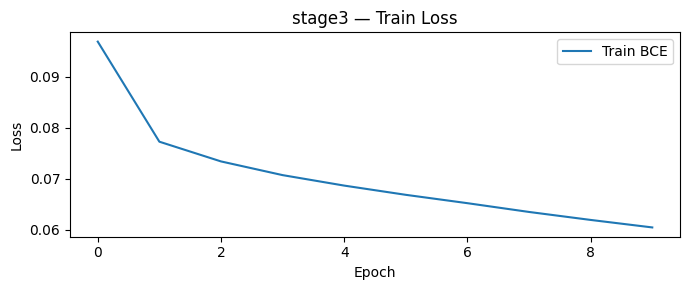

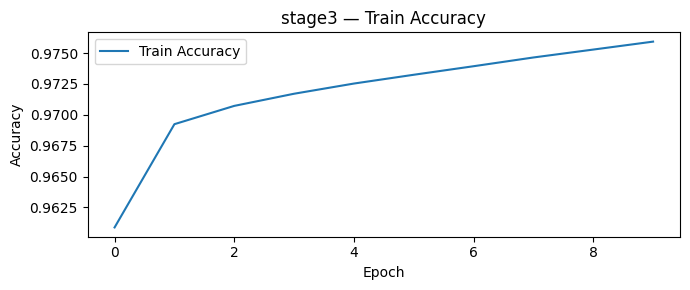

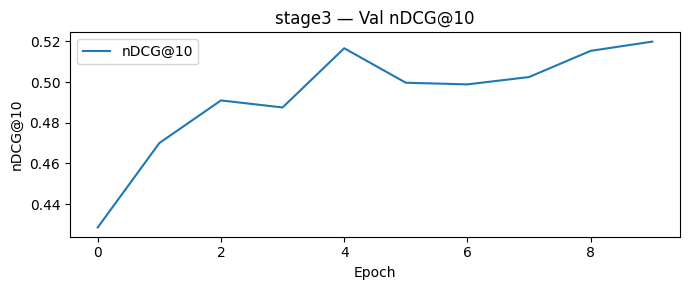

Loaded best weights from global_temporal_best_enhanced_ncf_stage3.pt


In [ ]:
num_numerical_stage3 = (
    len(ITEM_NUM_COLS_STAGE3)
    + len(USER_NUM_COLS_STAGE3)
    + len(PAIR_NUM_COLS_STAGE3)
)

model_s3 = FeatureEnhancedNCF(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=32,
    num_formats=num_formats,
    num_langs=num_langs,
    num_authors=num_authors,
    num_numerical=num_numerical_stage3,
    static_emb_dim=0 if item_sbert_matrix_s3 is None else item_sbert_matrix_s3.shape[1],
    dropout=0.5,
).to(DEVICE)

print("Training Stage 3...")
model_s3 = train_stage3(
    model=model_s3,
    train_loader=train_loader_s3,
    val_eval_users=val_eval_users,
    user_train_seen=user_train_seen,
    item_to_idx=item_to_idx,
    user_to_idx=user_to_idx,
    candidate_books=top_1000_books,
    stage_name="stage3",
    user_state_lookup=val_user_state_lookup,
    item_author_raw_by_idx=item_author_raw_by_idx,
    item_num_pages_raw_by_idx=item_num_pages_raw_by_idx,
    scaler_mean_map=scaler_mean_map,
    scaler_scale_map=scaler_scale_map,
    item_cat_matrix=item_cat_matrix_s3,
    item_num_matrix=item_num_matrix_s3,
    item_sbert_matrix=item_sbert_matrix_s3,
    num_epochs=10,
    patience=5,
    lr=0.001,
    monitor_metric=f"nDCG@{K}",
    eval_neg_samples=99,
)

In [ ]:
torch.save(
    model_s3.state_dict(),
    DATA_DIR + "global_temporal_best_enhanced_ncf_stage3.pt"
)

## Stage 3 Test Segment Analysis

After final test evaluation, Stage 1 performance is further analysed across user activity segments defined by the number of training interactions per user.

Two segmentations are used:
- **2-way split:** Non-sparse (`>= 5`) vs Sparse (`< 5`)
- **3-way split:** Low (`1–5`), Medium (`6–38`), and High (`39+`)

All segment-level results are computed on the sampled warm-start test users using the same ranking protocol as the main test evaluation, with **999 negatives per user**.

In [ ]:
# =========================================================
# 2-way user segmentation by TRAIN interaction count for Stage 3 test evaluation
# =========================================================
user_train_counts = train_df.groupby("user_id").size()

nonsparse_users = set(user_train_counts[user_train_counts >= 5].index)
sparse_users = set(user_train_counts[user_train_counts < 5].index)

print(f"Non-sparse users (>=5 train interactions): {len(nonsparse_users):,}")
print(f"Sparse users     (<5 train interactions): {len(sparse_users):,}")

segment_defs = [
    ("Non-sparse (>=5)", nonsparse_users),
    ("Sparse (<5)", sparse_users),
    ("All", None),
]

stage3_segment_results = {}

for seg_name, seg_set in segment_defs:
    if seg_set is None:
        seg_eval_users = test_eval_users
    else:
        seg_eval_users = [(uid, books) for uid, books in test_eval_users if uid in seg_set]

    print(f"\n{seg_name}: {len(seg_eval_users):,} eval users")

    if len(seg_eval_users) == 0:
        stage3_segment_results[seg_name] = None
        continue

    seg_results = evaluate_stage3(
        model=model_s3,
        eval_users=seg_eval_users,
        user_train_seen=user_train_seen,
        item_to_idx=item_to_idx,
        user_to_idx=user_to_idx,
        candidate_books=top_1000_books,
        stage_name=f"stage3_test_{seg_name}",
        user_state_lookup=test_user_state_lookup,
        item_author_raw_by_idx=item_author_raw_by_idx,
        item_num_pages_raw_by_idx=item_num_pages_raw_by_idx,
        scaler_mean_map=scaler_mean_map,
        scaler_scale_map=scaler_scale_map,
        item_cat_matrix=item_cat_matrix_s3,
        item_num_matrix=item_num_matrix_s3,
        item_sbert_matrix=item_sbert_matrix_s3,
        eval_neg_samples=999,
        seed=SEED,
    )

    stage3_segment_results[seg_name] = seg_results

print("\nStage 3 segmented test results:")
print(stage3_segment_results)

Non-sparse users (>=5 train interactions): 214,060
Sparse users     (<5 train interactions): 196,680

Non-sparse (>=5): 3,698 eval users


Evaluating stage3_test_Non-sparse (>=5):   0%|          | 0/3698 [00:00<?, ?it/s]


stage3_test_Non-sparse (>=5) — Results (K=10, 3,698 users)
HR@10  : 0.5327
MRR@10 : 0.4876
MAP@10 : 0.4876
nDCG@10: 0.4982

Sparse (<5): 1,302 eval users


Evaluating stage3_test_Sparse (<5):   0%|          | 0/1302 [00:00<?, ?it/s]


stage3_test_Sparse (<5) — Results (K=10, 1,302 users)
HR@10  : 0.4263
MRR@10 : 0.3698
MAP@10 : 0.3698
nDCG@10: 0.3833

All: 5,000 eval users


Evaluating stage3_test_All:   0%|          | 0/5000 [00:00<?, ?it/s]


stage3_test_All — Results (K=10, 5,000 users)
HR@10  : 0.5050
MRR@10 : 0.4570
MAP@10 : 0.4570
nDCG@10: 0.4683

Stage 3 segmented test results:
{'Non-sparse (>=5)': {'HR@10': 0.5327203893996755, 'MRR@10': np.float64(0.4876214727823702), 'MAP@10': np.float64(0.4876214727823702), 'nDCG@10': np.float64(0.4981921936821909)}, 'Sparse (<5)': {'HR@10': 0.42626728110599077, 'MRR@10': np.float64(0.3698443176553775), 'MAP@10': np.float64(0.3698443176553775), 'nDCG@10': np.float64(0.3833346723963715)}, 'All': {'HR@10': 0.505, 'MRR@10': np.float64(0.4569523015873012), 'MAP@10': np.float64(0.4569523015873012), 'nDCG@10': np.float64(0.46828329513936295)}}


In [ ]:
# =========================================================
# 3-way user segmentation by TRAIN interaction count for Stage 3 test evaluation
# =========================================================

def activity_bucket_3way(n):
    if n <= 5:
        return "Low (1-5)"
    elif n <= 38:
        return "Medium (6-38)"
    else:
        return "High (39+)"

user_train_counts = train_df.groupby("user_id").size()

low_users = set(user_train_counts[user_train_counts.apply(activity_bucket_3way) == "Low (1-5)"].index)
medium_users = set(user_train_counts[user_train_counts.apply(activity_bucket_3way) == "Medium (6-38)"].index)
high_users = set(user_train_counts[user_train_counts.apply(activity_bucket_3way) == "High (39+)"].index)

print(f"Low users    (1-5)   : {len(low_users):,}")
print(f"Medium users (6-38)  : {len(medium_users):,}")
print(f"High users   (39+)   : {len(high_users):,}")

segment_defs_3way = [
    ("Low (1-5)", low_users),
    ("Medium (6-38)", medium_users),
    ("High (39+)", high_users),
    ("All", None),
]

stage3_segment_results_3way = {}

for seg_name, seg_set in segment_defs_3way:
    if seg_set is None:
        seg_eval_users = test_eval_users
    else:
        seg_eval_users = [(uid, books) for uid, books in test_eval_users if uid in seg_set]

    print(f"\n{seg_name}: {len(seg_eval_users):,} eval users")

    if len(seg_eval_users) == 0:
        stage3_segment_results_3way[seg_name] = None
        continue

    seg_results = evaluate_stage3(
        model=model_s3,
        eval_users=seg_eval_users,
        user_train_seen=user_train_seen,
        item_to_idx=item_to_idx,
        user_to_idx=user_to_idx,
        candidate_books=top_1000_books,
        stage_name=f"stage3_test_{seg_name}",
        user_state_lookup=test_user_state_lookup,
        item_author_raw_by_idx=item_author_raw_by_idx,
        item_num_pages_raw_by_idx=item_num_pages_raw_by_idx,
        scaler_mean_map=scaler_mean_map,
        scaler_scale_map=scaler_scale_map,
        item_cat_matrix=item_cat_matrix_s3,
        item_num_matrix=item_num_matrix_s3,
        item_sbert_matrix=item_sbert_matrix_s3,
        eval_neg_samples=999,
        seed=SEED,
    )

    stage3_segment_results_3way[seg_name] = seg_results

print("\nStage 3 3-way segmented test results:")
print(stage3_segment_results_3way)

Low users    (1-5)   : 218,284
Medium users (6-38)  : 153,375
High users   (39+)   : 39,081

Low (1-5): 1,517 eval users


Evaluating stage3_test_Low (1-5):   0%|          | 0/1517 [00:00<?, ?it/s]


stage3_test_Low (1-5) — Results (K=10, 1,517 users)
HR@10  : 0.4417
MRR@10 : 0.3831
MAP@10 : 0.3831
nDCG@10: 0.3970

Medium (6-38): 2,203 eval users


Evaluating stage3_test_Medium (6-38):   0%|          | 0/2203 [00:00<?, ?it/s]


stage3_test_Medium (6-38) — Results (K=10, 2,203 users)
HR@10  : 0.4712
MRR@10 : 0.4187
MAP@10 : 0.4187
nDCG@10: 0.4310

High (39+): 1,280 eval users


Evaluating stage3_test_High (39+):   0%|          | 0/1280 [00:00<?, ?it/s]


stage3_test_High (39+) — Results (K=10, 1,280 users)
HR@10  : 0.6383
MRR@10 : 0.6104
MAP@10 : 0.6104
nDCG@10: 0.6170

All: 5,000 eval users


Evaluating stage3_test_All:   0%|          | 0/5000 [00:00<?, ?it/s]


stage3_test_All — Results (K=10, 5,000 users)
HR@10  : 0.5050
MRR@10 : 0.4570
MAP@10 : 0.4570
nDCG@10: 0.4683

Stage 3 3-way segmented test results:
{'Low (1-5)': {'HR@10': 0.4416611733684904, 'MRR@10': np.float64(0.3830591915957769), 'MAP@10': np.float64(0.3830591915957769), 'nDCG@10': np.float64(0.3970320457730174)}, 'Medium (6-38)': {'HR@10': 0.4711756695415343, 'MRR@10': np.float64(0.4186873599492758), 'MAP@10': np.float64(0.4186873599492758), 'nDCG@10': np.float64(0.43095665054029686)}, 'High (39+)': {'HR@10': 0.63828125, 'MRR@10': np.float64(0.610384734623016), 'MAP@10': np.float64(0.610384734623016), 'nDCG@10': np.float64(0.6169698133741199)}, 'All': {'HR@10': 0.505, 'MRR@10': np.float64(0.4569523015873012), 'MAP@10': np.float64(0.4569523015873012), 'nDCG@10': np.float64(0.46828329513936295)}}
